In [1]:
# ============================================================================
# CELDA 1: IMPORTS Y CONFIGURACIÓN
# ============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print(" Librerías cargadas")


# ============================================================================
# CELDA 2: PREPARACIÓN DE DATOS PARA SELECCIÓN
# ============================================================================
def preparar_para_seleccion(df, target_col):
    """
    Prepara el dataset para cálculo de MI:
    - Codifica categóricas de baja cardinalidad
    - Elimina columnas de alta cardinalidad sin codificar
    - Elimina columnas de fecha raw (usa las features temporales)
    """
    print("\n === PREPARACIÓN PARA SELECCIÓN DE FEATURES ===")
    
    df_prep = df.copy()
    
    # 1. Eliminar columnas de fecha raw (started_at, ended_at como timestamps)
    cols_fecha_raw = [col for col in df_prep.columns 
                      if df_prep[col].dtype == 'datetime64[ns]']
    if cols_fecha_raw:
        print(f"  ️ Eliminando {len(cols_fecha_raw)} columnas de fecha raw: {cols_fecha_raw}")
        df_prep = df_prep.drop(columns=cols_fecha_raw)
    
    # 2. Eliminar IDs y columnas de alta cardinalidad sin codificar
    cols_alta_card = [col for col in df_prep.select_dtypes(include=['object']).columns 
                      if df_prep[col].nunique() > 50]
    if cols_alta_card:
        print(f"   Eliminando {len(cols_alta_card)} columnas de alta cardinalidad sin codificar: {cols_alta_card[:5]}...")
        df_prep = df_prep.drop(columns=cols_alta_card)
    
    # 3. Codificar categóricas de baja cardinalidad (< 50 únicos)
    cols_categoricas = df_prep.select_dtypes(include=['object']).columns
    label_encoders = {}
    
    for col in cols_categoricas:
        if df_prep[col].nunique() < 50:
            le = LabelEncoder()
            df_prep[col] = le.fit_transform(df_prep[col].astype(str))
            label_encoders[col] = le
    
    print(f"  ✓ {len(cols_categoricas)} columnas categóricas codificadas")
    
    # 4. Separar features y target
    X = df_prep.drop(columns=[target_col])
    y = df_prep[target_col]
    
    # Codificar target si es categórico
    if y.dtype == 'object':
        le_target = LabelEncoder()
        y = le_target.fit_transform(y)
        print(f"  ✓ Target codificado: {le_target.classes_}")
    
    print(f"  ✓ Dataset preparado: {X.shape[1]} features")
    
    return X, y, label_encoders


# ============================================================================
# CELDA 3: SELECCIÓN CON MUTUAL INFORMATION (UMBRAL DINÁMICO)
# ============================================================================
def seleccion_mutual_info(X, y, tipo='clasificacion', top_n=20, umbral_percentil=70):
    """
    Calcula Mutual Information y selecciona variables usando percentil dinámico.
    """
    print(f"\n === SELECCIÓN POR MUTUAL INFORMATION ===")
    
    # Calcular MI
    if tipo == 'clasificacion':
        mi_scores = mutual_info_classif(X, y, random_state=42)
    else:
        mi_scores = mutual_info_regression(X, y, random_state=42)
    
    # Crear DataFrame ordenado
    df_mi = pd.DataFrame({
        'Feature': X.columns,
        'MI_Score': mi_scores
    }).sort_values('MI_Score', ascending=False)
    
    # Umbral dinámico: usar percentil en lugar de valor absoluto
    umbral = np.percentile(mi_scores, 100 - umbral_percentil)
    
    print(f"   Score máximo: {mi_scores.max():.4f}")
    print(f"   Score mínimo: {mi_scores.min():.4f}")
    print(f"   Umbral dinámico (percentil {umbral_percentil}): {umbral:.4f}")
    
    # Seleccionar variables
    variables_seleccionadas = df_mi[df_mi['MI_Score'] >= umbral]['Feature'].tolist()
    
    print(f"\n   Variables seleccionadas: {len(variables_seleccionadas)}")
    print(f"   Top {min(top_n, len(df_mi))}:")
    display(df_mi.head(top_n))
    
    return variables_seleccionadas, df_mi


# ============================================================================
# CELDA 4: SELECCIÓN CON RANDOM FOREST IMPORTANCE
# ============================================================================
def seleccion_random_forest(X, y, tipo='clasificacion', top_n=20, umbral_percentil=70):
    """
    Calcula importancia de variables con Random Forest.
    """
    print(f"\n === SELECCIÓN POR RANDOM FOREST ===")
    
    # Configurar modelo según tipo
    if tipo == 'clasificacion':
        rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    else:
        rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    
    # Entrenar
    rf.fit(X, y)
    
    # Crear DataFrame ordenado
    df_rf = pd.DataFrame({
        'Feature': X.columns,
        'RF_Importance': rf.feature_importances_
    }).sort_values('RF_Importance', ascending=False)
    
    # Umbral dinámico
    umbral = np.percentile(df_rf['RF_Importance'], 100 - umbral_percentil)
    
    print(f"   Importancia máxima: {df_rf['RF_Importance'].max():.4f}")
    print(f"   Umbral dinámico (percentil {umbral_percentil}): {umbral:.4f}")
    
    # Seleccionar variables
    variables_seleccionadas = df_rf[df_rf['RF_Importance'] >= umbral]['Feature'].tolist()
    
    print(f"\n   Variables seleccionadas: {len(variables_seleccionadas)}")
    print(f"   Top {min(top_n, len(df_rf))}:")
    display(df_rf.head(top_n))
    
    return variables_seleccionadas, df_rf


# ============================================================================
# CELDA 5: RANKING COMBINADO Y SELECCIÓN FINAL
# ============================================================================
def ranking_combinado(df_mi, df_rf, top_n=15):
    """
    Combina rankings de MI y RF para obtener un consenso.
    """
    print("\n === RANKING COMBINADO ===")
    
    # Normalizar scores a [0, 1]
    df_mi_norm = df_mi.copy()
    df_mi_norm['MI_Score'] = (df_mi_norm['MI_Score'] - df_mi_norm['MI_Score'].min()) / \
                             (df_mi_norm['MI_Score'].max() - df_mi_norm['MI_Score'].min())
    
    df_rf_norm = df_rf.copy()
    df_rf_norm['RF_Importance'] = (df_rf_norm['RF_Importance'] - df_rf_norm['RF_Importance'].min()) / \
                                  (df_rf_norm['RF_Importance'].max() - df_rf_norm['RF_Importance'].min())
    
    # Merge
    df_combined = df_mi_norm.merge(df_rf_norm, on='Feature', how='outer').fillna(0)
    
    # Score combinado (promedio)
    df_combined['Score_Combinado'] = (df_combined['MI_Score'] + df_combined['RF_Importance']) / 2
    df_combined = df_combined.sort_values('Score_Combinado', ascending=False)
    
    print(f"   Top {top_n} variables por ranking combinado:")
    display(df_combined.head(top_n))
    
    # Seleccionar top N
    variables_finales = df_combined.head(top_n)['Feature'].tolist()
    
    print(f"\n   Variables finales seleccionadas: {len(variables_finales)}")
    print(f"   Lista: {variables_finales}")
    
    return variables_finales, df_combined


# ============================================================================
# CELDA 6: FUNCIÓN MAESTRA
# ============================================================================
def seleccionar_features(df, target_col, tipo='clasificacion', 
                         top_n_final=15, umbral_percentil=70):
    """
    Función maestra de selección de características.
    """
    print("="*80)
    print(" SELECCIÓN DE CARACTERÍSTICAS")
    print("="*80)
    
    # 1. Preparar datos
    X, y, encoders = preparar_para_seleccion(df, target_col)
    
    # 2. Mutual Information
    vars_mi, df_mi = seleccion_mutual_info(X, y, tipo, umbral_percentil=umbral_percentil)
    
    # 3. Random Forest
    vars_rf, df_rf = seleccion_random_forest(X, y, tipo, umbral_percentil=umbral_percentil)
    
    # 4. Ranking combinado
    vars_finales, df_combined = ranking_combinado(df_mi, df_rf, top_n=top_n_final)
    
    # 5. Dataset final
    df_final = df[vars_finales + [target_col]].copy()
    
    print("\n" + "="*80)
    print(" SELECCIÓN COMPLETADA")
    print("="*80)
    print(f"\n Resumen:")
    print(f"  - Variables originales: {df.shape[1] - 1}")
    print(f"  - Variables seleccionadas: {len(vars_finales)}")
    print(f"  - Reducción: {((df.shape[1] - 1 - len(vars_finales)) / (df.shape[1] - 1) * 100):.1f}%")
    
    return df_final, vars_finales, df_combined


# ============================================================================
# CELDA 7: EJEMPLO DE USO
# ============================================================================
"""
# Para tu dataset de bicicletas:
df_final, variables_seleccionadas, ranking = seleccionar_features(
    df=df_procesado,  # Tu dataset después del notebook de conversión
    target_col='member_casual',
    tipo='clasificacion',
    top_n_final=15,
    umbral_percentil=70  # Selecciona el top 30% de variables
)

# Ver resultado
print("\n Variables seleccionadas:")
print(variables_seleccionadas)
display(df_final.head())
"""

print("\n Notebook listo. Ejecuta: df_final, vars, ranking = seleccionar_features(df, 'member_casual')")

 Librerías cargadas

 Notebook listo. Ejecuta: df_final, vars, ranking = seleccionar_features(df, 'member_casual')


In [5]:
import pandas as pd

# 1. Primero cargamos el dataset en memoria
df = pd.read_csv("dataset_limpio.csv")
print(f"✓ Dataset cargado: {df.shape}")

# 2. Ahora sí, pasamos la variable 'df' (no el nombre del archivo)
df_final, variables_seleccionadas, ranking = seleccionar_features(
    df=df, 
    target_col='critical_temp',
    tipo='regresion',
    top_n_final=57,
    umbral_percentil=70
)

✓ Dataset cargado: (21197, 82)
 SELECCIÓN DE CARACTERÍSTICAS

 === PREPARACIÓN PARA SELECCIÓN DE FEATURES ===
  ✓ 0 columnas categóricas codificadas
  ✓ Dataset preparado: 81 features

 === SELECCIÓN POR MUTUAL INFORMATION ===
   Score máximo: 0.9504
   Score mínimo: 0.1203
   Umbral dinámico (percentil 70): 0.6457

   Variables seleccionadas: 57
   Top 20:


,Feature,MI_Score
19,std_fie,0.950446
33,gmean_Density,0.948910
69,std_ThermalConductivity,0.935851
5,entropy_atomic_mass,0.929451
25,entropy_atomic_radius,0.923118
35,entropy_Density,0.914835
45,entropy_ElectronAffinity,0.910373
17,range_fie,0.909743
47,range_ElectronAffinity,0.907048
55,entropy_FusionHeat,0.898894



 === SELECCIÓN POR RANDOM FOREST ===
   Importancia máxima: 0.5385
   Umbral dinámico (percentil 70): 0.0017

   Variables seleccionadas: 57
   Top 20:


,Feature,RF_Importance
67,range_ThermalConductivity,0.538508
64,wtd_gmean_ThermalConductivity,0.126355
74,wtd_gmean_Valence,0.019743
39,std_Density,0.018007
9,std_atomic_mass,0.014803
66,wtd_entropy_ThermalConductivity,0.011786
72,wtd_mean_Valence,0.011604
31,mean_Density,0.011204
78,wtd_range_Valence,0.010428
8,wtd_range_atomic_mass,0.009667



 === RANKING COMBINADO ===
   Top 57 variables por ranking combinado:


,Feature,MI_Score,RF_Importance,Score_Combinado
28,range_ThermalConductivity,0.758331,1.000000,0.879166
8,gmean_Density,0.998150,0.013198,0.505674
40,std_fie,1.000000,0.002184,0.501092
36,std_ThermalConductivity,0.982419,0.002835,0.492627
5,entropy_atomic_mass,0.974710,0.003036,0.488873
0,entropy_Density,0.957103,0.014368,0.485735
6,entropy_atomic_radius,0.967081,0.004332,0.485707
52,wtd_gmean_ThermalConductivity,0.720848,0.234563,0.477706
32,range_fie,0.950970,0.002966,0.476968
1,entropy_ElectronAffinity,0.951728,0.002138,0.476933



   Variables finales seleccionadas: 57
   Lista: ['range_ThermalConductivity', 'gmean_Density', 'std_fie', 'std_ThermalConductivity', 'entropy_atomic_mass', 'entropy_Density', 'entropy_atomic_radius', 'wtd_gmean_ThermalConductivity', 'range_fie', 'entropy_ElectronAffinity', 'range_ElectronAffinity', 'entropy_FusionHeat', 'wtd_gmean_Valence', 'std_ElectronAffinity', 'mean_ThermalConductivity', 'gmean_FusionHeat', 'wtd_mean_Valence', 'gmean_ElectronAffinity', 'range_Density', 'std_atomic_radius', 'gmean_ThermalConductivity', 'entropy_fie', 'entropy_Valence', 'mean_FusionHeat', 'gmean_atomic_mass', 'std_Density', 'wtd_gmean_Density', 'mean_Density', 'mean_ElectronAffinity', 'range_atomic_mass', 'range_atomic_radius', 'std_atomic_mass', 'wtd_std_ThermalConductivity', 'wtd_gmean_FusionHeat', 'range_FusionHeat', 'gmean_atomic_radius', 'std_FusionHeat', 'gmean_Valence', 'mean_atomic_mass', 'entropy_ThermalConductivity', 'wtd_gmean_atomic_radius', 'mean_fie', 'wtd_std_fie', 'wtd_mean_FusionHe

In [15]:
def seleccion_por_propiedad_base(df):
    """
    Reduce las 81 features derivadas a ~17 features base, 
    conservando solo la media y la desviación estándar (o entropía) 
    de cada propiedad atómica.
    """
    print("\n=== SELECCIÓN POR PROPIEDAD BASE (Enfoque de Dominio) ===")
    
    propiedades_base = [
        'atomic_mass', 'fie', 'atomic_radius', 'Density', 
        'ElectronAffinity', 'FusionHeat', 'ThermalConductivity', 'Valence'
    ]
    
    features_seleccionadas = ['number_of_elements'] # Esta siempre se queda
    
    for prop in propiedades_base:
        # Conservamos la media (tendencia central) y el std (dispersión)
        # Puedes cambiar 'std' por 'entropy' si tu EDA mostró que la entropía es mejor
        features_seleccionadas.append(f'mean_{prop}')
        features_seleccionadas.append(f'std_{prop}')
        
        # Opcional: Si quieres agregar una tercera métrica por propiedad:
        # features_seleccionadas.append(f'entropy_{prop}')
    
    # Filtrar solo las que realmente existen en el dataframe
    features_finales = [f for f in features_seleccionadas if f in df.columns]
    
    print(f"  → Features originales: {df.shape[1]}")
    print(f"  → Features seleccionadas: {len(features_finales)}")
    print(f"  → Lista: {features_finales}")
    
    return df[features_finales]

# Aplicar:
X_reducido = seleccion_por_propiedad_base(X)


=== SELECCIÓN POR PROPIEDAD BASE (Enfoque de Dominio) ===
  → Features originales: 81
  → Features seleccionadas: 17
  → Lista: ['number_of_elements', 'mean_atomic_mass', 'std_atomic_mass', 'mean_fie', 'std_fie', 'mean_atomic_radius', 'std_atomic_radius', 'mean_Density', 'std_Density', 'mean_ElectronAffinity', 'std_ElectronAffinity', 'mean_FusionHeat', 'std_FusionHeat', 'mean_ThermalConductivity', 'std_ThermalConductivity', 'mean_Valence', 'std_Valence']


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_regression

def seleccion_mi_con_codo_y_decorrelacion(X, y, umbral_correlacion=0.90, varianza_objetivo_mi=0.95):
    """
    Selección de features usando Mutual Information, Método del Codo 
    y decorrelación progresiva para evitar redundancia.
    """
    print("="*80)
    print(" SELECCIÓN: MI + MÉTODO DEL CODO + DECORRELACIÓN")
    print("="*80)
    print(f"  → Evaluando {X.shape[1]} features con Mutual Information (Regresión)...")
    
    # 1. Calcular Mutual Information
    # random_state para reproducibilidad en tu tesis
    mi_scores = mutual_info_regression(X, y, random_state=42, n_neighbors=5)
    
    mi_df = pd.DataFrame({
        'Feature': X.columns,
        'MI_Score': mi_scores
    })
    
    # Ordenar de mayor a menor MI
    mi_df = mi_df.sort_values('MI_Score', ascending=False).reset_index(drop=True)
    
    # Calcular MI acumulado (para el método del codo)
    mi_df['MI_Acumulado'] = mi_df['MI_Score'].cumsum()
    mi_df['Porcentaje_Acumulado'] = mi_df['MI_Acumulado'] / mi_df['MI_Acumulado'].iloc[-1]
    
    # 2. Visualización del Método del Codo
    plt.figure(figsize=(14, 6))
    
    # Gráfico de barras (MI individual)
    plt.bar(range(len(mi_df)), mi_df['MI_Score'], alpha=0.6, label='MI Score Individual', color='skyblue')
    
    # Gráfico de línea (MI Acumulado)
    plt.plot(range(len(mi_df)), mi_df['Porcentaje_Acumulado'], 
             color='red', marker='o', linewidth=2, label='MI Acumulado (%)')
    
    # Línea de corte objetivo (ej. 95%)
    idx_objetivo = (mi_df['Porcentaje_Acumulado'] >= varianza_objetivo_mi).idxmax()
    plt.axvline(x=idx_objetivo, color='green', linestyle='--', 
                label=f'Corte sugerido ({varianza_objetivo_mi*100}%): {idx_objetivo+1} features')
    
    plt.title('Método del Codo: Mutual Information Acumulada', fontsize=14, fontweight='bold')
    plt.xlabel('Número de Features (ordenadas por MI)', fontsize=12)
    plt.ylabel('MI Score / Porcentaje Acumulado', fontsize=12)
    plt.xticks(range(0, len(mi_df), 5))
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # 3. Selección progresiva con decorrelación (La clave del éxito)
    print(f"\n=== APLICANDO DECORRELACIÓN PROGRESIVA (Umbral corr: {umbral_correlacion}) ===")
    
    features_seleccionadas = []
    
    for _, row in mi_df.iterrows():
        feat = row['Feature']
        
        if len(features_seleccionadas) == 0:
            # La primera (la de mayor MI) siempre se selecciona
            features_seleccionadas.append(feat)
        else:
            # Calcular la correlación máxima de esta feature con las YA seleccionadas
            correlaciones = X[features_seleccionadas].corrwith(X[feat]).abs()
            max_corr = correlaciones.max()
            
            # Si no está altamente correlacionada con ninguna de las seleccionadas, la agregamos
            if max_corr < umbral_correlacion:
                features_seleccionadas.append(feat)
    
    print(f"\n  → Features totales evaluadas: {len(mi_df)}")
    print(f"  → Features seleccionadas tras decorrelación: {len(features_seleccionadas)}")
    
    # 4. Mostrar las features seleccionadas
    df_final = mi_df[mi_df['Feature'].isin(features_seleccionadas)].copy()
    df_final['Ranking'] = range(1, len(df_final) + 1)
    
    print(f"\n  Top {len(df_final)} Features Seleccionadas:")
    display(df_final[['Ranking', 'Feature', 'MI_Score', 'Porcentaje_Acumulado']].head(20))
    
    return features_seleccionadas, df_final

# ==============================================================================
# CÓMO USARLO
# ==============================================================================
# Asumiendo que X tiene tus 81 features e y es 'critical_temp'
# features_finales, df_resumen = seleccion_mi_con_codo_y_decorrelacion(X, y, umbral_correlacion=0.90, varianza_objetivo_mi=0.95)

# X_limpio = X[features_finales]
# print(f"\n✓ Dataset final listo para modelar: {X_limpio.shape[1]} features")

 SELECCIÓN: MI + MÉTODO DEL CODO + DECORRELACIÓN
  → Evaluando 81 features con Mutual Information (Regresión)...


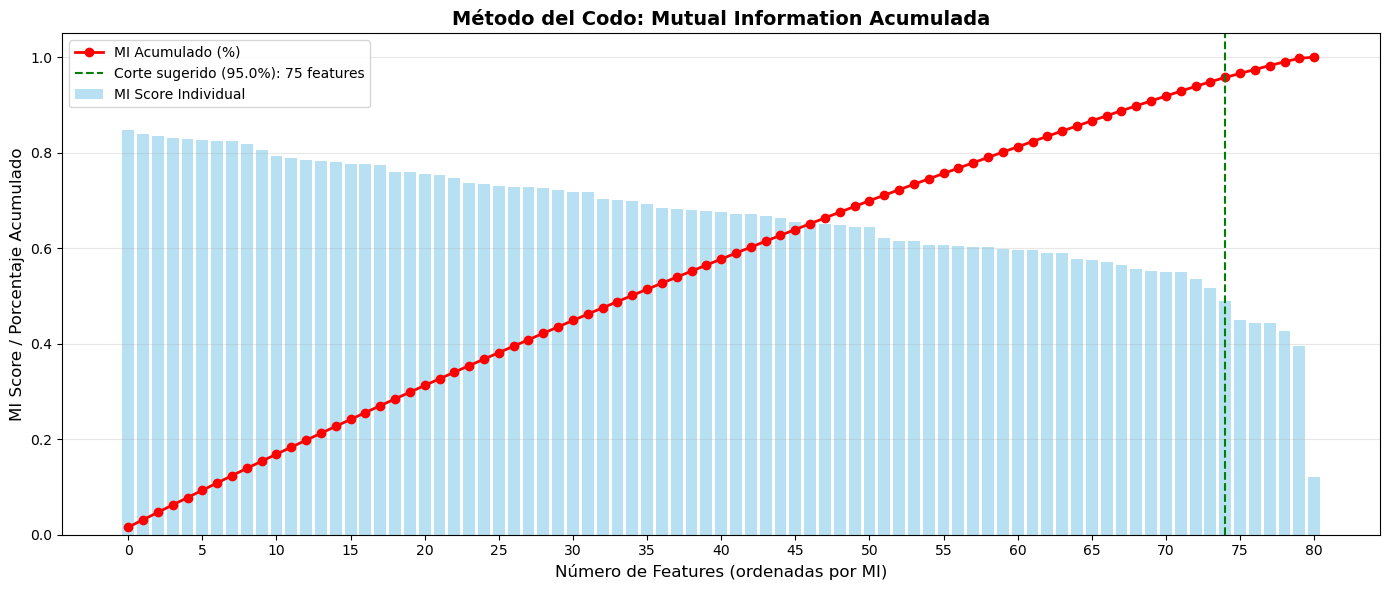


=== APLICANDO DECORRELACIÓN PROGRESIVA (Umbral corr: 0.7) ===

  → Features totales evaluadas: 81
  → Features seleccionadas tras decorrelación: 23

  Top 23 Features Seleccionadas:


,Ranking,Feature,MI_Score,Porcentaje_Acumulado
0,1,range_fie,0.847286,0.015751
3,2,range_ElectronAffinity,0.830810,0.062319
7,3,std_ThermalConductivity,0.824286,0.123756
9,4,range_Density,0.806493,0.153959
10,5,entropy_Density,0.793510,0.168710
17,6,mean_ThermalConductivity,0.774005,0.270245
19,7,gmean_FusionHeat,0.758755,0.298485
22,8,range_atomic_mass,0.747163,0.340417
24,9,gmean_ThermalConductivity,0.734425,0.367745
26,10,range_FusionHeat,0.729088,0.394861


In [18]:
X = df.drop("critical_temp", axis = 1)
y = df["critical_temp"]
features_finales, df_resumen = seleccion_mi_con_codo_y_decorrelacion(X, y, umbral_correlacion=0.70, varianza_objetivo_mi=0.95)

In [19]:
# Asumiendo que 'features_finales' es la lista de las 23 features que seleccionaste
# y 'X' es tu DataFrame original con todas las features

# 1. Crear DataFrame con las features seleccionadas
X_final = X[features_finales]

# 2. Agregar el target (critical_temp)
df_final = X_final.copy()
df_final['critical_temp'] = y

# 3. Guardar el dataset limpio
df_final.to_csv('dataset_final_23features.csv', index=False)

print(f"✓ Dataset guardado: dataset_final_23features.csv")
print(f"  → Shape: {df_final.shape}")
print(f"  → Features: {list(df_final.columns)}")

# 4. (Opcional) Guardar también la lista de features para referencia
with open('features_seleccionadas.txt', 'w') as f:
    for i, feat in enumerate(features_finales, 1):
        f.write(f"{i}. {feat}\n")

print(f"✓ Lista de features guardada: features_seleccionadas.txt")

✓ Dataset guardado: dataset_final_23features.csv
  → Shape: (21197, 24)
  → Features: ['range_fie', 'range_ElectronAffinity', 'std_ThermalConductivity', 'range_Density', 'entropy_Density', 'mean_ThermalConductivity', 'gmean_FusionHeat', 'range_atomic_mass', 'gmean_ThermalConductivity', 'range_FusionHeat', 'gmean_ElectronAffinity', 'gmean_atomic_mass', 'wtd_range_FusionHeat', 'entropy_ThermalConductivity', 'gmean_atomic_radius', 'wtd_range_ThermalConductivity', 'wtd_mean_atomic_radius', 'wtd_range_ElectronAffinity', 'wtd_range_Valence', 'std_Valence', 'wtd_range_Density', 'wtd_range_fie', 'wtd_entropy_fie', 'critical_temp']
✓ Lista de features guardada: features_seleccionadas.txt


In [20]:
# Ver las primeras filas
display(df_final.head())

# Ver estadísticas básicas
print("\nEstadísticas del dataset final:")
print(df_final.describe().T)

,range_fie,range_ElectronAffinity,std_ThermalConductivity,range_Density,entropy_Density,mean_ThermalConductivity,gmean_FusionHeat,range_atomic_mass,gmean_ThermalConductivity,range_FusionHeat,...,gmean_atomic_radius,wtd_range_ThermalConductivity,wtd_mean_atomic_radius,wtd_range_ElectronAffinity,wtd_range_Valence,std_Valence,wtd_range_Density,wtd_range_fie,wtd_entropy_fie,critical_temp
0,810.6,127.05,168.854244,8958.571,1.033129,107.756645,3.479475,122.90607,7.062488,12.878,...,136.126003,57.127669,105.514286,80.987143,1.085714,0.433013,1579.583429,735.985714,0.791488,29.0
1,810.6,127.05,198.554600,10488.571,1.314442,172.205316,4.403790,122.90607,16.064228,12.878,...,141.465215,51.413383,104.971429,81.207857,1.128571,0.632456,1667.383429,743.164286,0.807078,26.0
2,810.6,127.05,168.854244,8958.571,1.033129,107.756645,3.479475,122.90607,7.062488,12.878,...,136.126003,57.127669,104.685714,81.207857,1.114286,0.433013,1667.383429,743.164286,0.773620,19.0
3,810.6,127.05,168.854244,8958.571,1.033129,107.756645,3.479475,122.90607,7.062488,12.878,...,136.126003,57.127669,105.100000,81.097500,1.100000,0.433013,1623.483429,739.575000,0.783207,22.0
4,810.6,127.05,168.854244,8958.571,1.033129,107.756645,3.479475,122.90607,7.062488,12.878,...,136.126003,57.127669,106.342857,80.766429,1.057143,0.433013,1491.783429,728.807143,0.805230,23.0



Estadísticas del dataset final:
                                 count         mean          std        min  \
range_fie                      21197.0   573.413988   309.205105   0.000000   
range_ElectronAffinity         21197.0   120.868857    58.679836   0.000000   
std_ThermalConductivity        21197.0    99.127605    60.108851   0.000000   
range_Density                  21197.0  8673.258150  4093.005329   0.000000   
entropy_Density                21197.0     1.073272     0.342333   0.000000   
mean_ThermalConductivity       21197.0    89.762371    38.514224   0.026580   
gmean_FusionHeat               21197.0    10.102742    10.049735   0.222000   
range_atomic_mass              21197.0   115.751945    54.584784   0.000000   
gmean_ThermalConductivity      21197.0    29.765853    34.054177   0.026580   
range_FusionHeat               21197.0    21.109508    20.321781   0.000000   
gmean_ElectronAffinity         21197.0    54.307039    29.000902   1.500000   
gmean_atomic_mass  